In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("moazeldsokyx/dogs-vs-cats")

print("Path to dataset files:", path)

100%|██████████| 817M/817M [00:10<00:00, 82.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/moazeldsokyx/dogs-vs-cats/versions/1


In [5]:


import zipfile

path="/content/archive.zip"
with zipfile.ZipFile(path, 'r') as zip_ref:
    zip_ref.extractall("/content/")


In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [7]:
# Define image dimensions and batch size
IMG_WIDTH, IMG_HEIGHT = 150, 150
BATCH_SIZE = 32

# Create an ImageDataGenerator for data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # 20% for validation
)

# Load and preprocess training data
train_generator = train_datagen.flow_from_directory(
    '/content/dataset/train',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary', # Assuming binary classification (cats vs. dogs)
    subset='training'
)

# Load and preprocess validation data
validation_generator = train_datagen.flow_from_directory(
    '/content/dataset/validation', # Same directory, using validation split
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


Found 16000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


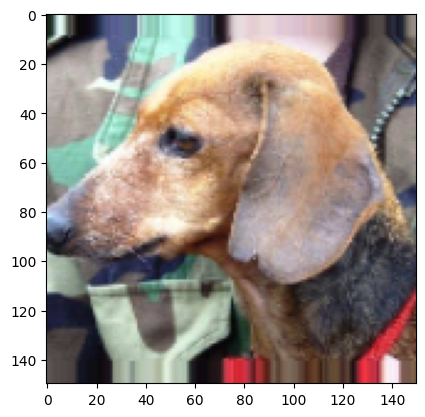

In [8]:
import matplotlib.pyplot as plt

# Access the first image in the first batch
first_image = train_generator[1][0][1]

plt.imshow(first_image)
plt.show()

In [9]:
from tensorflow.keras import layers, models

model = models.Sequential()
# Conv Block 1
model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150, 150, 3))) # Input shape adjusted
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.25))
# Conv Block 2
model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.25))
# Conv Block 3
model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.4))
# Fully Connected Layers
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid')) # Output layer for binary classification


model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,597,985 (21.35 MB)

 Trainable params: 5,596,833 (21.35 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [10]:
# prompt: model train koro

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=10, # You might need to increase this for better results
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

# Save the trained model
model.save('cats_vs_dogs_model.h5')







/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 137s 241ms/step - accuracy: 0.6045 - loss: 0.7807 - val_accuracy: 0.6986 - val_loss: 0.5810
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 118s 235ms/step - accuracy: 0.7181 - loss: 0.5538 - val_accuracy: 0.5756 - val_loss: 1.0180
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 233ms/step - accuracy: 0.7615 - loss: 0.4837 - val_accuracy: 0.7419 - val_loss: 0.5475
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 236ms/step - accuracy: 0.8091 - loss: 0.4198 - val_accuracy: 0.7560 - val_loss: 0.5024
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 118s 236ms/step - accuracy: 0.8300 - loss: 0.3831 - val_accuracy: 0.6593 - val_loss: 0.6440
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 120s 239ms/step - accuracy: 0.8568 - loss: 0.3299 - val_accuracy: 0.6462 - val_loss: 0.8083
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 238ms/step - accuracy: 0.8795 - loss: 0.2934 - val_accuracy: 0.8710 - val_loss: 0.2796
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 235ms/step - accuracy: 0.8984 -

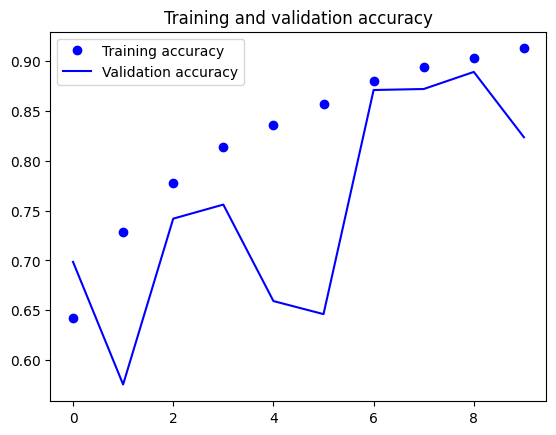

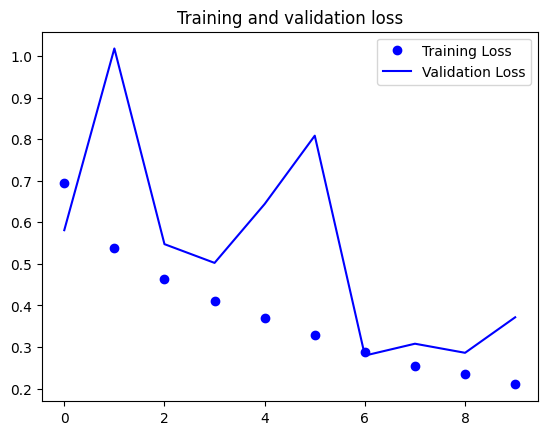

In [11]:
# Plot training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))


plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model('cats_vs_dogs_model.h5')

# Function to predict the class of an image
def predict_image(image_path):
    img = image.load_img(image_path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.  # Normalize the image

    prediction = model.predict(img_array)
    if prediction[0][0] > 0.5:
        return "Dog"
    else:
        return "Cat"

# Example usage:
image_path = '/content/KOA_Nassau_2697x1517.jpg' # Replace with the actual path to your image
predicted_class = predict_image(image_path)
print(f"The predicted class for the image is: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
The predicted class for the image is: Dog
